# Finding the limits of logistical regression on this data


In [86]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sys

from pathlib import Path


# Own functions
# Necessary to import from src dir
sys.path.append("../..")
import src.preprocessing_minimal as ppm

## Reading in the data

In [87]:
data_dir = Path('../data')
output_dir = Path('../outputs')

In [88]:
import re

def combine_features(df: pd.DataFrame) -> pd.DataFrame:
    patterns = {
        "CO2_combined.mean":   rf"CO2\d{{2,3}}\.mean",
        "H2O_combined.mean":   rf"H2O\d{{2,3}}\.mean",
        "NO_combined.mean":    rf"NO\d{{2,3}}\.mean",
        "NOx_combined.mean":   rf"NOx\d{{2,3}}\.mean",
        "O3_combined.mean":    rf"O3\d{{2,3}}\.mean",
        "RHIRGA_combined.mean":rf"RHIRGA\d{{2,3}}\.mean",
        "T_combined.mean":     rf"T\d{{2,3}}\.mean",
        "CO2_combined.std":    rf"CO2\d{{2,3}}\.std",
        "H2O_combined.std":    rf"H2O\d{{2,3}}\.std",
        "NO_combined.std":     rf"NO\d{{2,3}}\.std",
        "NOx_combined.std":    rf"NOx\d{{2,3}}\.std",
        "O3_combined.std":     rf"O3\d{{2,3}}\.std",
        "RHIRGA_combined.std": rf"RHIRGA\d{{2,3}}\.std",
        "T_combined.std":      rf"T\d{{2,3}}\.std",
    }

    df = df.copy()

    for new_col, pattern in patterns.items():
        matching_cols = [c for c in df.columns if re.fullmatch(pattern, c)]
        if matching_cols:
            df[new_col] = df[matching_cols].mean(axis=1)
            df.drop(columns=matching_cols, inplace=True)

    return df

## Logistic regression

In [99]:
#Fitting logistic regression to class2
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, log_loss

#Data management
train_df = ppm.preprocess_train_data(data_dir / 'train.csv',drop_std=False)
X_train, y_train2, y_train4 = ppm.split_xy(train_df)
ev_ne_scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = ev_ne_scaler.fit_transform(X_train)

c_accuracies = []
c_perplexities = []

for c in np.linspace(0.1, 1.0, 50):
    log_model = LogisticRegression(C=c, l1_ratio=1, solver='liblinear', max_iter=1000)
    avg_accuracies = []
    avg_perplexities = []
    for i in range(5):
        accuracies = []
        perplexities = []
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42 + i)
        for train_index, test_index in skf.split(X_train_scaled, y_train2):
            X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
            y_train_fold, y_test_fold = y_train2.iloc[train_index], y_train2.iloc[test_index]

            log_model.fit(X_train_fold, y_train_fold)
            
            y_pred_fold = log_model.predict(X_test_fold)
            y_pred_prob_fold = log_model.predict_proba(X_test_fold)[:, 1]

            binary_accuracy = accuracy_score(y_test_fold, y_pred_fold)
            perplexity = np.exp(log_loss(y_test_fold, y_pred_prob_fold))
            accuracies.append(binary_accuracy)
            perplexities.append(perplexity)
        avg_accuracies.append(np.mean(accuracies))
        avg_perplexities.append(np.mean(perplexities))

    c_accuracies.append(avg_accuracies)
    c_perplexities.append(avg_perplexities)

# Trainig the best model on the whole training set
mean_c_accuracies = [np.mean(accs) for accs in c_accuracies]
best_c_index = np.argmax(mean_c_accuracies)
best_c = np.linspace(0.1, 1.0, 50)[best_c_index]
mean_c_perplexities = [np.mean(perps) for perps in c_perplexities]

print(f"Best C: {best_c:.4f} "
      f"with Average Accuracy: {mean_c_accuracies[best_c_index]:.4f} "
      f"and Average Perplexity: {mean_c_perplexities[best_c_index]:.4f}")

Best C: 0.3571 with Average Accuracy: 0.8956 and Average Perplexity: 1.3512


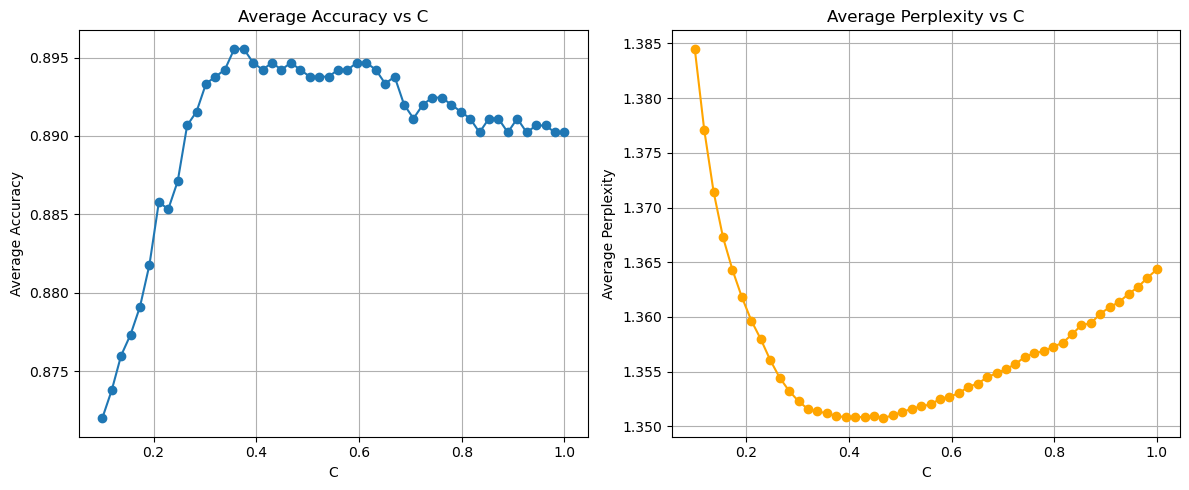

In [100]:
#plotting the accuracy and perplexity against C
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(np.linspace(0.1, 1.0, 50), mean_c_accuracies, marker='o')
plt.title('Average Accuracy vs C')
plt.xlabel('C')
plt.ylabel('Average Accuracy')
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(np.linspace(0.1, 1.0, 50), mean_c_perplexities, marker='o', color='orange')
plt.title('Average Perplexity vs C')
plt.xlabel('C')
plt.ylabel('Average Perplexity')
plt.grid()
plt.tight_layout()
plt.show()

If accuracy and perplexity peak at different C, we can tune two different models.

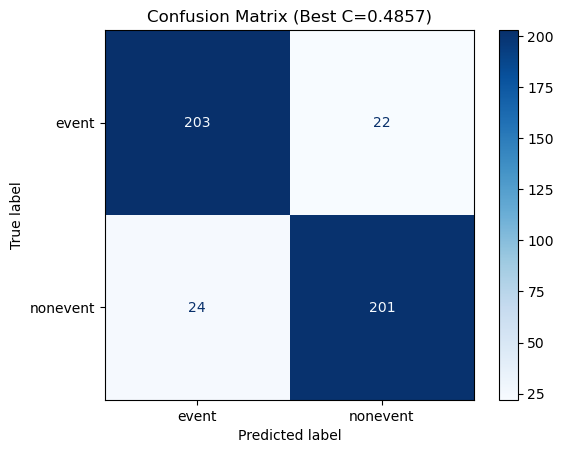

In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model = LogisticRegression(C=best_c, l1_ratio=1, solver='liblinear')
all_preds = []
all_true = []

for train_index, test_index in skf.split(X_train_scaled, y_train2):
    X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
    y_train_fold, y_test_fold = y_train2.iloc[train_index], y_train2.iloc[test_index]
    best_model.fit(X_train_fold, y_train_fold)
    all_preds.extend(best_model.predict(X_test_fold))
    all_true.extend(y_test_fold)

cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix (Best C={best_c:.4f})")
plt.show()

## Logistic regression with PCA

In [70]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, log_loss

#Data management
train_df = ppm.preprocess_train_data(data_dir / 'train.csv',drop_std=False)
X_train, y_train2, y_train4 = ppm.split_xy(train_df)
ev_ne_scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = ev_ne_scaler.fit_transform(X_train)

X_test_final = pd.read_csv(data_dir / 'test.csv').drop(columns=["partlybad", "date", "id"])
X_test_final_scaled = ev_ne_scaler.transform(X_test_final)

c_accuracies = []
c_perplexities = []

for n in range(1, 30):
    c = 0.3
#for c in np.linspace(0.1, 1.0, 50):
    pca = PCA(n_components=n)#, random_state=42)
    log_model = LogisticRegression(C=c, l1_ratio=1, solver='liblinear')
    avg_accuracies = []
    avg_perplexities = []
    for i in range(5):
        accuracies = []
        perplexities = []
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42 + i)
        for train_index, test_index in skf.split(X_train_scaled, y_train2):
            X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
            y_train_fold, y_test_fold = y_train2.iloc[train_index], y_train2.iloc[test_index]
            #pca.fit(X_train_fold)
            pca.fit(pd.concat([X_train_fold, X_test_final_scaled]))
            pca_train_fold = pca.transform(X_train_fold)
            pca_test_fold = pca.transform(X_test_fold)
            log_model.fit(pca_train_fold, y_train_fold)
            
            y_pred_fold = log_model.predict(pca_test_fold)
            y_pred_prob_fold = log_model.predict_proba(pca_test_fold)[:, 1]

            binary_accuracy = accuracy_score(y_test_fold, y_pred_fold)
            perplexity = np.exp(log_loss(y_test_fold, y_pred_prob_fold))
            accuracies.append(binary_accuracy)
            perplexities.append(perplexity)
        avg_accuracies.append(np.mean(accuracies))
        avg_perplexities.append(np.mean(perplexities))

    c_accuracies.append(avg_accuracies)
    c_perplexities.append(avg_perplexities)

# Trainig the best model on the whole training set
mean_n_accuracies = [np.mean(accs) for accs in c_accuracies]
best_n_index = np.argmax(mean_n_accuracies)
best_n = best_n_index + 1
mean_n_perplexities = [np.mean(perps) for perps in c_perplexities]

print(f"Best Number of PCA Components: {best_n} "
      f"with Average Accuracy: {mean_n_accuracies[best_n_index]:.4f} "
      f"and Average Perplexity: {mean_n_perplexities[best_n_index]:.4f}")

Best Number of PCA Components: 27 with Average Accuracy: 0.8853 and Average Perplexity: 1.3672


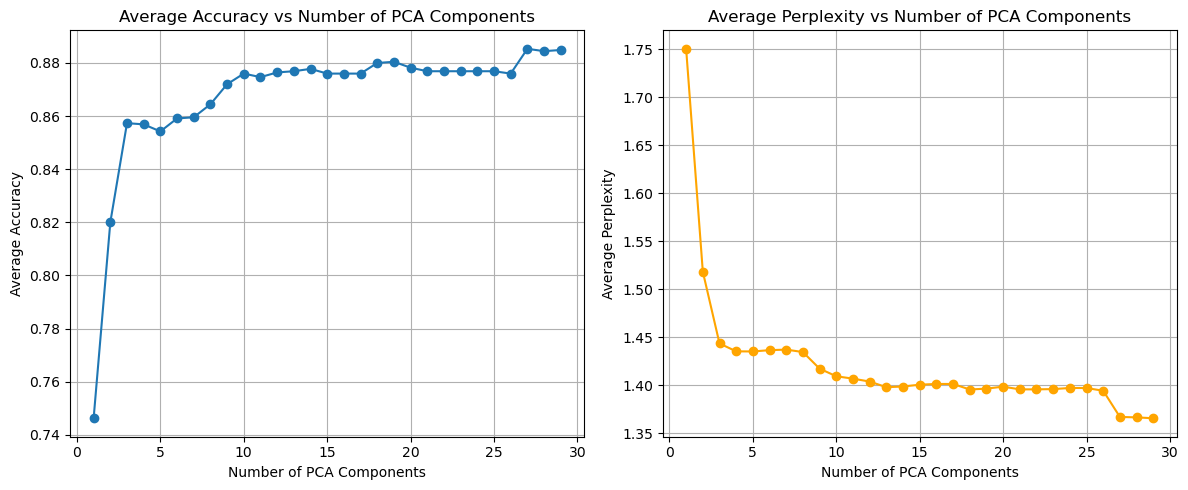

In [71]:
#Plot the accuracy and perplexity against the number of PCA components
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, 30), mean_n_accuracies, marker='o')
plt.title('Average Accuracy vs Number of PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Average Accuracy')
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(range(1, 30), mean_n_perplexities, marker='o', color='orange')
plt.title('Average Perplexity vs Number of PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Average Perplexity')
plt.grid()
plt.tight_layout()
plt.show()

Conclusion: PCA makes the event/nonevent regression worse.

## Next classifying into I and II

In [72]:
#Fitting logistic regression to class2
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, log_loss

#Data management
train_df = ppm.preprocess_train_data(data_dir / 'train.csv',drop_std=False)
train_df.class4 = train_df.class4.replace({'Ia': 'I', 'Ib':'I'})
#Drop nonevent samples for class4
train_df = train_df[train_df['class4'] != 'nonevent']
X_train, y_train2, y_train4 = ppm.split_xy(train_df)

I_II_scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = I_II_scaler.fit_transform(X_train)

c_accuracies = []
c_perplexities = []

for c in np.linspace(0.01, 0.3, 50):
    log_model = LogisticRegression(C=c, l1_ratio=1, solver='liblinear')
    avg_accuracies = []
    avg_perplexities = []
    for i in range(5):
        accuracies = []
        perplexities = []
        skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42 + i**2)
        for train_index, test_index in skf.split(X_train_scaled, y_train4):
            X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
            y_train_fold, y_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]
            log_model.fit(X_train_fold, y_train_fold)
            
            y_pred_fold = log_model.predict(X_test_fold)
            y_pred_prob_fold = log_model.predict_proba(X_test_fold)[:, 1]


            binary_accuracy = accuracy_score(y_test_fold, y_pred_fold)
            perplexity = np.exp(log_loss(y_test_fold, y_pred_prob_fold))
            accuracies.append(binary_accuracy)
            perplexities.append(perplexity)
        avg_accuracies.append(np.mean(accuracies))
        avg_perplexities.append(np.mean(perplexities))

    c_accuracies.append(avg_accuracies)
    c_perplexities.append(avg_perplexities)

# Trainig the best model on the whole training set
mean_c_accuracies_I_II = [np.mean(accs) for accs in c_accuracies]
best_c_index_I_II = np.argmax(mean_c_accuracies_I_II)
best_c_I_II = np.linspace(0.01, 0.3, 50)[best_c_index_I_II]
mean_c_perplexities_I_II = [np.mean(perps) for perps in c_perplexities]



print(f"Best C: {best_c_I_II:.4f} "
      f"with Average Accuracy: {mean_c_accuracies_I_II[best_c_index_I_II]:.4f} "
      f"and Average Perplexity: {mean_c_perplexities_I_II[best_c_index_I_II]:.4f}")

Best C: 0.1520 with Average Accuracy: 0.6622 and Average Perplexity: 1.9159


## XGboost on the I/II classification

In [73]:
import numpy as np
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, log_loss
from sklearn.preprocessing import LabelEncoder

train_df = ppm.preprocess_train_data(data_dir / 'train.csv',drop_std=False)
train_df.class4 = train_df.class4.replace({'Ia': 'I', 'Ib':'I'})
#Drop nonevent samples for class4
train_df = train_df[train_df['class4'] != 'nonevent']
X_train, y_train2, y_train4 = ppm.split_xy(train_df)

# XGBoost requires numeric labels
le = LabelEncoder()
y_train4_enc = le.fit_transform(y_train4)  # e.g. 'I' -> 0, 'II' -> 1

# Parameter grid
param_grid = {
    'max_depth':      [1,2,3],
    'learning_rate':  [0.2],
    'subsample':      [0.7],
    'colsample_bytree': [0.75,0.8,0.85]
}

results = []

total = (len(param_grid['max_depth']) * len(param_grid['learning_rate']) *
         len(param_grid['subsample']) * len(param_grid['colsample_bytree']))
done = 0

for max_depth in param_grid['max_depth']:
    for lr in param_grid['learning_rate']:
        for subsample in param_grid['subsample']:
            for colsample in param_grid['colsample_bytree']:

                fold_accuracies = []
                fold_losses = []
                best_iterations = []

                skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

                for train_idx, test_idx in skf.split(X_train, y_train4_enc):
                    X_tr = X_train.iloc[train_idx]
                    X_te = X_train.iloc[test_idx]
                    y_tr = y_train4_enc[train_idx]
                    y_te = y_train4_enc[test_idx]

                    model = XGBClassifier(
                        n_estimators=1000,          # high ceiling, early stop cuts it
                        max_depth=max_depth,
                        learning_rate=lr,
                        subsample=subsample,
                        colsample_bytree=colsample,
                        early_stopping_rounds=30,   # stop if no improvement for 30 rounds
                        eval_metric='logloss',
                        random_state=42,
                        verbosity=0
                    )

                    model.fit(
                        X_tr, y_tr,
                        eval_set=[(X_te, y_te)],
                        verbose=False
                    )

                    y_pred = model.predict(X_te)
                    y_proba = model.predict_proba(X_te)[:, 1]

                    fold_accuracies.append(accuracy_score(y_te, y_pred))
                    fold_losses.append(log_loss(y_te, y_proba))
                    best_iterations.append(model.best_iteration)

                results.append({
                    'max_depth':        max_depth,
                    'learning_rate':    lr,
                    'subsample':        subsample,
                    'colsample_bytree': colsample,
                    'mean_accuracy':    np.mean(fold_accuracies),
                    'std_accuracy':     np.std(fold_accuracies),
                    'mean_logloss':     np.mean(fold_losses),
                    'mean_best_iter':   int(np.mean(best_iterations))
                })

                done += 1
                if done % 10 == 0:
                    print(f"Progress: {done}/{total}")

# --- Find best result ---
results_df = pd.DataFrame(results).sort_values('mean_accuracy', ascending=False)
print(results_df.head(10).to_string(index=False))

best = results_df.iloc[0]
print(f"\nBest params:")
print(f"  max_depth:        {int(best.max_depth)}")
print(f"  learning_rate:    {best.learning_rate}")
print(f"  subsample:        {best.subsample}")
print(f"  colsample_bytree: {best.colsample_bytree}")
print(f"  mean n_estimators:{int(best.mean_best_iter)}")
print(f"  mean accuracy:    {best.mean_accuracy:.4f} ± {best.std_accuracy:.4f}")
print(f"  mean logloss:     {best.mean_logloss:.4f}")

# --- Retrain final model on all data with best params ---
final_model = XGBClassifier(
    n_estimators=int(best.mean_best_iter),  # use average best iteration from CV
    max_depth=int(best.max_depth),
    learning_rate=best.learning_rate,
    subsample=best.subsample,
    colsample_bytree=best.colsample_bytree,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

final_model.fit(X_train, y_train4_enc)

# Decode predictions back to original labels
y_test_pred_enc = final_model.predict(X_test_final)
y_test_pred = le.inverse_transform(y_test_pred_enc)

 max_depth  learning_rate  subsample  colsample_bytree  mean_accuracy  std_accuracy  mean_logloss  mean_best_iter
         2            0.2        0.7              0.75       0.680000      0.033259      0.634034               7
         2            0.2        0.7              0.80       0.653333      0.026667      0.638908               8
         1            0.2        0.7              0.75       0.644444      0.037185      0.623835              21
         2            0.2        0.7              0.85       0.640000      0.008889      0.631364              10
         1            0.2        0.7              0.85       0.635556      0.063790      0.622563              16
         3            0.2        0.7              0.85       0.631111      0.073837      0.634164               8
         3            0.2        0.7              0.80       0.631111      0.057263      0.634476               6
         3            0.2        0.7              0.75       0.626667      0.035556     

In [74]:
final_model = XGBClassifier(
    n_estimators=7,  # use average best iteration from CV
    max_depth=2,
    learning_rate=0.2,
    subsample=0.7,
    colsample_bytree=0.75,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

In [75]:
print(int(best.mean_best_iter))

7


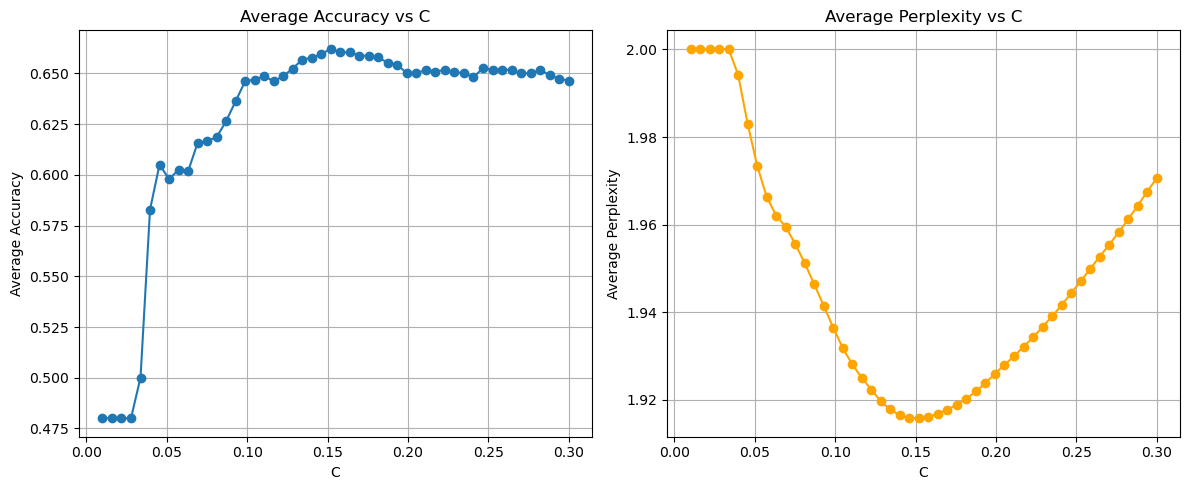

In [76]:
#plotting the accuracy and perplexity against C
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(np.linspace(0.01, 0.3, 50), mean_c_accuracies_I_II, marker='o')
plt.title('Average Accuracy vs C')
plt.xlabel('C')
plt.ylabel('Average Accuracy')
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(np.linspace(0.01, 0.3, 50), mean_c_perplexities_I_II, marker='o', color='orange')
plt.title('Average Perplexity vs C')
plt.xlabel('C')
plt.ylabel('Average Perplexity')
plt.grid()
plt.tight_layout()
plt.show()

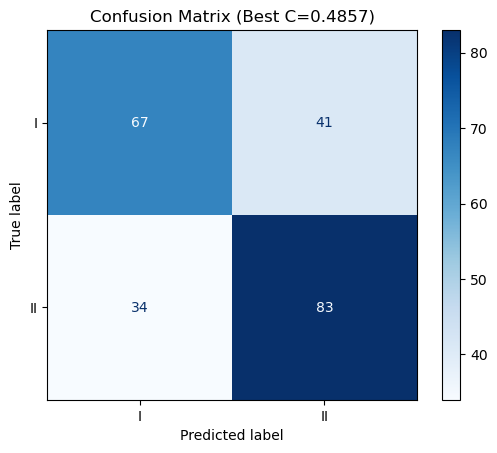

In [77]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model = LogisticRegression(C=best_c_I_II, l1_ratio=1, solver='liblinear')
all_preds = []
all_true = []

for train_index, test_index in skf.split(X_train_scaled, y_train4):
    X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
    y_train_fold, y_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]
    best_model.fit(X_train_fold, y_train_fold)
    all_preds.extend(best_model.predict(X_test_fold))
    all_true.extend(y_test_fold)

cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix (Best C={best_c:.4f})")
plt.show()

## Class I/II classification with PCA:

In [78]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, log_loss

#Data management
train_df = ppm.preprocess_train_data(data_dir / 'train.csv',drop_std=False)
train_df.class4 = train_df.class4.replace({'Ia': 'I', 'Ib':'I'})
#Drop nonevent samples for class4
train_df = train_df[train_df['class4'] != 'nonevent']
X_train, y_train2, y_train4 = ppm.split_xy(train_df)
I_II_scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = I_II_scaler.fit_transform(X_train)

X_test_final = pd.read_csv(data_dir / 'test.csv').drop(columns=["partlybad", "date", "id"])
X_test_final_scaled = I_II_scaler.transform(X_test_final)

c_accuracies = []
c_perplexities = []

for n in range(1, 30):
    c = 0.3
#for c in np.linspace(0.1, 1.0, 50):
    pca = PCA(n_components=n)#, random_state=42)
    log_model = LogisticRegression(C=c, l1_ratio=1, solver='liblinear')
    avg_accuracies = []
    avg_perplexities = []
    for i in range(5):
        accuracies = []
        perplexities = []
        skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42 + i)
        for train_index, test_index in skf.split(X_train_scaled, y_train4):
            X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
            y_train_fold, y_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]
            #pca.fit(X_train_fold)
            pca.fit(pd.concat([X_train_fold, X_test_final_scaled]))
            pca_train_fold = pca.transform(X_train_fold)
            pca_test_fold = pca.transform(X_test_fold)
            log_model.fit(pca_train_fold, y_train_fold)
            
            y_pred_fold = log_model.predict(pca_test_fold)
            y_pred_prob_fold = log_model.predict_proba(pca_test_fold)[:, 1]

            binary_accuracy = accuracy_score(y_test_fold, y_pred_fold)
            perplexity = np.exp(log_loss(y_test_fold, y_pred_prob_fold))
            accuracies.append(binary_accuracy)
            perplexities.append(perplexity)
        avg_accuracies.append(np.mean(accuracies))
        avg_perplexities.append(np.mean(perplexities))

    c_accuracies.append(avg_accuracies)
    c_perplexities.append(avg_perplexities)

# Trainig the best model on the whole training set
mean_n_accuracies = [np.mean(accs) for accs in c_accuracies]
best_n_index = np.argmax(mean_n_accuracies)
best_n = best_n_index + 1
mean_n_perplexities = [np.mean(perps) for perps in c_perplexities]

print(f"Best Number of PCA Components: {best_n} "
      f"with Average Accuracy: {mean_n_accuracies[best_n_index]:.4f} "
      f"and Average Perplexity: {mean_n_perplexities[best_n_index]:.4f}")

Best Number of PCA Components: 6 with Average Accuracy: 0.6651 and Average Perplexity: 1.8909


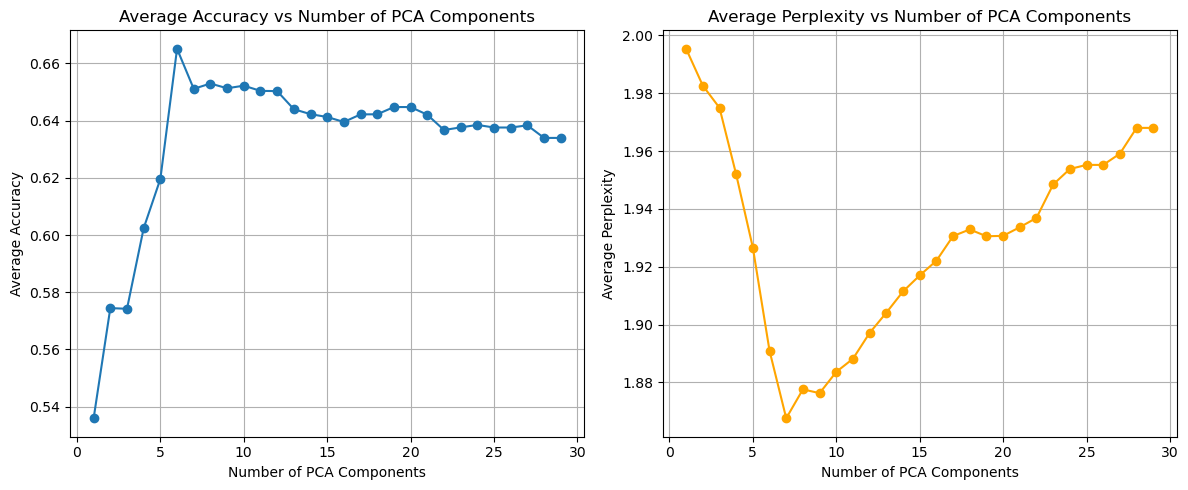

In [79]:
#Plot the accuracy and perplexity against the number of PCA components
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, 30), mean_n_accuracies, marker='o')
plt.title('Average Accuracy vs Number of PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Average Accuracy')
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(range(1, 30), mean_n_perplexities, marker='o', color='orange')
plt.title('Average Perplexity vs Number of PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Average Perplexity')
plt.grid()
plt.tight_layout()
plt.show()

Conclusion: PCA makes this also worse

## And then Ia Ib classification

In [80]:
#Fitting logistic regression to class2
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, log_loss

#Data management
train_df = ppm.preprocess_train_data(data_dir / 'train.csv',drop_std=False)
#Drop nonevent samples for class4
train_df = train_df[train_df['class4'] != 'nonevent']
train_df = train_df[train_df['class4'] != 'II']
X_train, y_train2, y_train4 = ppm.split_xy(train_df)


IA_IB_scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = IA_IB_scaler.fit_transform(X_train)

c_accuracies = []
c_perplexities = []

for c in np.linspace(0.01, 1.0, 50):
    log_model = LogisticRegression(C=c, l1_ratio=1, solver='liblinear')
    avg_accuracies = []
    avg_perplexities = []
    for i in range(5):
        accuracies = []
        perplexities = []
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42 + i)
        for train_index, test_index in skf.split(X_train_scaled, y_train4):
            X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
            y_train_fold, y_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]
            log_model.fit(X_train_fold, y_train_fold)
            
            y_pred_fold = log_model.predict(X_test_fold)
            y_pred_prob_fold = log_model.predict_proba(X_test_fold)[:, 1]

            binary_accuracy = accuracy_score(y_test_fold, y_pred_fold)
            perplexity = np.exp(log_loss(y_test_fold, y_pred_prob_fold))
            accuracies.append(binary_accuracy)
            perplexities.append(perplexity)
        avg_accuracies.append(np.mean(accuracies))
        avg_perplexities.append(np.mean(perplexities))

    c_accuracies.append(avg_accuracies)
    c_perplexities.append(avg_perplexities)

# Trainig the best model on the whole training set
mean_c_accuracies_IA_IB = [np.mean(accs) for accs in c_accuracies]
best_c_index_IA_IB = np.argmax(mean_c_accuracies_IA_IB)
best_c_IA_IB = np.linspace(0.01, 1.0, 50)[best_c_index_IA_IB]
mean_c_perplexities_IA_IB = [np.mean(perps) for perps in c_perplexities]

print(f"Best C: {best_c_IA_IB:.4f} "
      f"with Average Accuracy: {mean_c_accuracies_IA_IB[best_c_index_IA_IB]:.4f} "
      f"and Average Perplexity: {mean_c_perplexities_IA_IB[best_c_index_IA_IB]:.4f}")

Best C: 0.2120 with Average Accuracy: 0.7743 and Average Perplexity: 1.6885


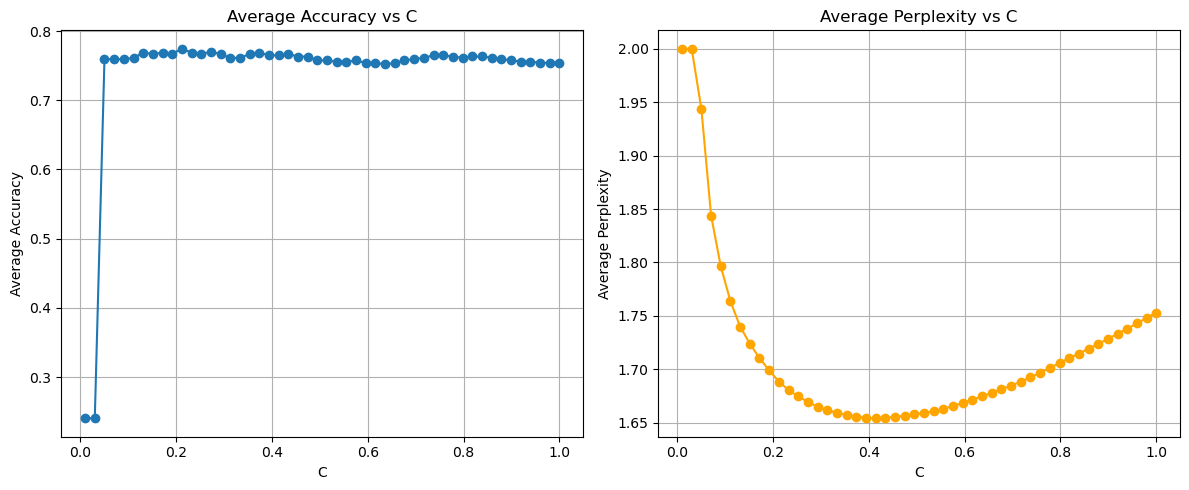

In [81]:
#plotting the accuracy and perplexity against C
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(np.linspace(0.01, 1.0, 50), mean_c_accuracies_IA_IB, marker='o')
plt.title('Average Accuracy vs C')
plt.xlabel('C')
plt.ylabel('Average Accuracy')
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(np.linspace(0.01, 1.0, 50), mean_c_perplexities_IA_IB, marker='o', color='orange')
plt.title('Average Perplexity vs C')
plt.xlabel('C')
plt.ylabel('Average Perplexity')
plt.grid()
plt.tight_layout()
plt.show()

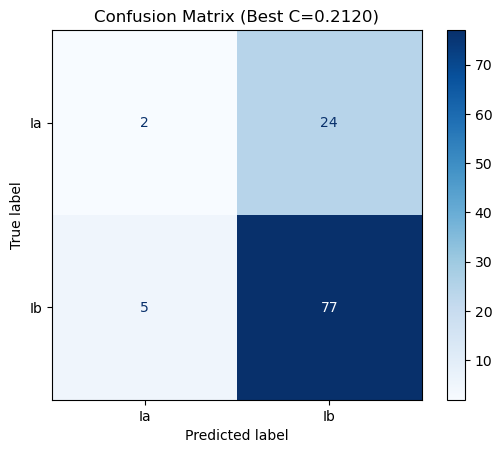

In [82]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model = LogisticRegression(C=best_c_IA_IB, l1_ratio=1, solver='liblinear')
all_preds = []
all_true = []

for train_index, test_index in skf.split(X_train_scaled, y_train4):
    X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
    y_train_fold, y_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]
    best_model.fit(X_train_fold, y_train_fold)
    all_preds.extend(best_model.predict(X_test_fold))
    all_true.extend(y_test_fold)

cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix (Best C={best_c_IA_IB:.4f})")
plt.show()

## Ia/Ib with xgboost:

In [83]:
import numpy as np
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, log_loss
from sklearn.preprocessing import LabelEncoder

train_df = ppm.preprocess_train_data(data_dir / 'train.csv',drop_std=False)
train_df = train_df[train_df['class4'] != 'nonevent']
train_df = train_df[train_df['class4'] != 'II']
X_train, y_train2, y_train4 = ppm.split_xy(train_df)

# XGBoost requires numeric labels
le = LabelEncoder()
y_train4_enc = le.fit_transform(y_train4)  # e.g. 'I' -> 0, 'II' -> 1

# Parameter grid
param_grid = {
    'max_depth':      [1,2,3],
    'learning_rate':  [0.2],
    'subsample':      [0.7],
    'colsample_bytree': [0.75,0.8,0.85]
}

results = []

total = (len(param_grid['max_depth']) * len(param_grid['learning_rate']) *
         len(param_grid['subsample']) * len(param_grid['colsample_bytree']))
done = 0

for max_depth in param_grid['max_depth']:
    for lr in param_grid['learning_rate']:
        for subsample in param_grid['subsample']:
            for colsample in param_grid['colsample_bytree']:

                fold_accuracies = []
                fold_losses = []
                best_iterations = []

                skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

                for train_idx, test_idx in skf.split(X_train, y_train4_enc):
                    X_tr = X_train.iloc[train_idx]
                    X_te = X_train.iloc[test_idx]
                    y_tr = y_train4_enc[train_idx]
                    y_te = y_train4_enc[test_idx]

                    model = XGBClassifier(
                        n_estimators=1000,          # high ceiling, early stop cuts it
                        max_depth=max_depth,
                        learning_rate=lr,
                        subsample=subsample,
                        colsample_bytree=colsample,
                        early_stopping_rounds=30,   # stop if no improvement for 30 rounds
                        eval_metric='logloss',
                        random_state=42,
                        verbosity=0
                    )

                    model.fit(
                        X_tr, y_tr,
                        eval_set=[(X_te, y_te)],
                        verbose=False
                    )

                    y_pred = model.predict(X_te)
                    y_proba = model.predict_proba(X_te)[:, 1]

                    fold_accuracies.append(accuracy_score(y_te, y_pred))
                    fold_losses.append(log_loss(y_te, y_proba))
                    best_iterations.append(model.best_iteration)

                results.append({
                    'max_depth':        max_depth,
                    'learning_rate':    lr,
                    'subsample':        subsample,
                    'colsample_bytree': colsample,
                    'mean_accuracy':    np.mean(fold_accuracies),
                    'std_accuracy':     np.std(fold_accuracies),
                    'mean_logloss':     np.mean(fold_losses),
                    'mean_best_iter':   int(np.mean(best_iterations))
                })

                done += 1
                if done % 10 == 0:
                    print(f"Progress: {done}/{total}")

# --- Find best result ---
results_df = pd.DataFrame(results).sort_values('mean_accuracy', ascending=False)
print(results_df.head(10).to_string(index=False))

best = results_df.iloc[0]
print(f"\nBest params:")
print(f"  max_depth:        {int(best.max_depth)}")
print(f"  learning_rate:    {best.learning_rate}")
print(f"  subsample:        {best.subsample}")
print(f"  colsample_bytree: {best.colsample_bytree}")
print(f"  mean n_estimators:{int(best.mean_best_iter)}")
print(f"  mean accuracy:    {best.mean_accuracy:.4f} ± {best.std_accuracy:.4f}")
print(f"  mean logloss:     {best.mean_logloss:.4f}")

# --- Retrain final model on all data with best params ---
final_model = XGBClassifier(
    n_estimators=int(best.mean_best_iter),  # use average best iteration from CV
    max_depth=int(best.max_depth),
    learning_rate=best.learning_rate,
    subsample=best.subsample,
    colsample_bytree=best.colsample_bytree,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

final_model.fit(X_train, y_train4_enc)

# Decode predictions back to original labels
y_test_pred_enc = final_model.predict(X_test_final)
y_test_pred = le.inverse_transform(y_test_pred_enc)

 max_depth  learning_rate  subsample  colsample_bytree  mean_accuracy  std_accuracy  mean_logloss  mean_best_iter
         1            0.2        0.7              0.75       0.814719      0.030414      0.468247              39
         3            0.2        0.7              0.75       0.805628      0.034534      0.481950              19
         1            0.2        0.7              0.85       0.796537      0.035985      0.470923              23
         3            0.2        0.7              0.80       0.796537      0.035985      0.490783              10
         2            0.2        0.7              0.75       0.796104      0.023963      0.487398              12
         2            0.2        0.7              0.80       0.796104      0.023963      0.478822              16
         3            0.2        0.7              0.85       0.787879      0.043355      0.483830              18
         1            0.2        0.7              0.80       0.787446      0.045370     

## Ia/Ib classification with PCA

In [84]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, log_loss

#Data management
train_df = ppm.preprocess_train_data(data_dir / 'train.csv',drop_std=False)
#Drop nonevent samples for class4
train_df = train_df[train_df['class4'] != 'nonevent']
train_df = train_df[train_df['class4'] != 'II']
X_train, y_train2, y_train4 = ppm.split_xy(train_df)
Ia_Ib_scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = Ia_Ib_scaler.fit_transform(X_train)

X_test_final = pd.read_csv(data_dir / 'test.csv').drop(columns=["partlybad", "date", "id"])
X_test_final_scaled = Ia_Ib_scaler.transform(X_test_final)

c_accuracies = []
c_perplexities = []

for n in range(1, 30):
    c = 0.3
#for c in np.linspace(0.1, 1.0, 50):
    pca = PCA(n_components=n)#, random_state=42)
    log_model = LogisticRegression(C=c, l1_ratio=1, solver='liblinear')
    avg_accuracies = []
    avg_perplexities = []
    for i in range(5):
        accuracies = []
        perplexities = []
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42 + i)
        for train_index, test_index in skf.split(X_train_scaled, y_train4):
            X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
            y_train_fold, y_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]
            #pca.fit(X_train_fold)
            pca.fit(pd.concat([X_train_fold, X_test_final_scaled]))
            pca_train_fold = pca.transform(X_train_fold)
            pca_test_fold = pca.transform(X_test_fold)
            log_model.fit(pca_train_fold, y_train_fold)
            
            y_pred_fold = log_model.predict(pca_test_fold)
            y_pred_prob_fold = log_model.predict_proba(pca_test_fold)[:, 1]

            binary_accuracy = accuracy_score(y_test_fold, y_pred_fold)
            perplexity = np.exp(log_loss(y_test_fold, y_pred_prob_fold))
            accuracies.append(binary_accuracy)
            perplexities.append(perplexity)
        avg_accuracies.append(np.mean(accuracies))
        avg_perplexities.append(np.mean(perplexities))

    c_accuracies.append(avg_accuracies)
    c_perplexities.append(avg_perplexities)

# Trainig the best model on the whole training set
mean_n_accuracies = [np.mean(accs) for accs in c_accuracies]
best_n_index = np.argmax(mean_n_accuracies)
best_n = best_n_index + 1
mean_n_perplexities = [np.mean(perps) for perps in c_perplexities]

print(f"Best Number of PCA Components: {best_n} "
      f"with Average Accuracy: {mean_n_accuracies[best_n_index]:.4f} "
      f"and Average Perplexity: {mean_n_perplexities[best_n_index]:.4f}")

Best Number of PCA Components: 2 with Average Accuracy: 0.7869 and Average Perplexity: 1.7107


In [85]:
#Plot the accuracy and perplexity against the number of PCA components
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, 30), mean_n_accuracies, marker='o')
plt.title('Average Accuracy vs Number of PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Average Accuracy')
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(range(1, 30), mean_n_perplexities, marker='o', color='orange')
plt.title('Average Perplexity vs Number of PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Average Perplexity')
plt.grid()
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

Conclusion: PCA makes this also worse

This provides marginally better results than dummy model which predicts only Ib

## Combining models and running tests

In [ ]:
#Fitting logistic regression to class2
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss

#Data management
train_df = ppm.preprocess_train_data(data_dir / 'train.csv',drop_std=False)
X_train, y_train2, y_train4 = ppm.split_xy(train_df)
ev_ne_scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = ev_ne_scaler.fit_transform(X_train)

log_model = LogisticRegression(C=0.37, l1_ratio=1, solver='liblinear')
avg_binary_accuracies = []
avg_binary_accuracies_i_ii = []
avg_multi_accuracies_dummy1 = []
avg_multi_accuracies_dummy2 = []
avg_perplexities = []
for i in range(5):
    binary_accuracies = []
    binary_accuracies_i_ii = []
    multi_accuracies_dummy1 = []
    multi_accuracies_dummy2 = []
    perplexities = []
    skf = StratifiedKFold(n_splits=10, shuffle=True)#, random_state=42 + i**2)
    for train_index, test_index in skf.split(X_train_scaled, y_train2):
        X_train_fold, X_test_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[test_index]
        y2_train_fold, y2_test_fold = y_train2.iloc[train_index], y_train2.iloc[test_index]
        y4_train_fold, y4_test_fold = y_train4.iloc[train_index], y_train4.iloc[test_index]
        
        #First model to eveluate event/nonevent classification
        #Dropping event type II
        
        log_model.fit(X_train_fold, y2_train_fold)
        y_pred_fold = log_model.predict(X_test_fold)
        y_pred_prob_fold = log_model.predict_proba(X_test_fold)[:, 0]

        #Dummy model which expects event = II
        y_multi_pred_fold = np.where(y_pred_fold == 'event', 'II', 'nonevent')

        binary_accuracies.append(accuracy_score(y2_test_fold, y_pred_fold))
        multi_accuracies_dummy1.append(accuracy_score(y4_test_fold, y_multi_pred_fold))
        perplexities.append(np.exp(log_loss(y2_test_fold, 1 - y_pred_prob_fold)))

        #Removing nonevents and predicting events into I/II
        nonevent_mask_train = y4_train_fold != 'nonevent'
        nonevent_mask_test = y4_test_fold != 'nonevent'
        X_i_ii_train_fold = X_train_fold[nonevent_mask_train]
        X_i_ii_test_fold = X_test_fold[nonevent_mask_test]
        Y4_i_ii_train_fold = y4_train_fold[nonevent_mask_train]
        Y4_i_ii_test_fold = y4_test_fold[nonevent_mask_test]
        #Naming Ia and Ib as I for the I/II classification
        Y4_i_ii_train_fold = Y4_i_ii_train_fold.replace({'Ia': 'Ib'})
        Y4_i_ii_test_fold = Y4_i_ii_test_fold.replace({'Ia': 'Ib'})

        #Scaling the data again for the I/II classification
        i_ii_scaler = StandardScaler().set_output(transform="pandas")
        X_i_ii_train_fold_scaled = i_ii_scaler.fit_transform(X_i_ii_train_fold)
        #Scaling the test fold 
        X_i_ii_test_fold_scaled = i_ii_scaler.transform(X_i_ii_test_fold)
        X_test_fold_i_ii_scaled = i_ii_scaler.transform(X_test_fold)
        #Fitting the model for I/II classification
        i_ii_log_model = LogisticRegression(C=0.17, l1_ratio=1, solver='liblinear')
        i_ii_log_model.fit(X_i_ii_train_fold_scaled, Y4_i_ii_train_fold)
        y_i_ii_pred_fold = i_ii_log_model.predict(X_i_ii_test_fold_scaled)
        binary_accuracies_i_ii.append(accuracy_score(Y4_i_ii_test_fold, y_i_ii_pred_fold))
        y_i_ii_pred_fold = i_ii_log_model.predict(X_test_fold_i_ii_scaled)
        #Replacing the predicted I/II back into the original test fold predictions
        y_multi_pred_fold = np.where(y_multi_pred_fold == 'II', y_i_ii_pred_fold, y_multi_pred_fold)
        multi_accuracies_dummy2.append(accuracy_score(y4_test_fold, y_multi_pred_fold))

    avg_binary_accuracies.append(np.mean(binary_accuracies))
    avg_binary_accuracies_i_ii.append(np.mean(binary_accuracies_i_ii))
    avg_multi_accuracies_dummy1.append(np.mean(multi_accuracies_dummy1))
    avg_multi_accuracies_dummy2.append(np.mean(multi_accuracies_dummy2))
    avg_perplexities.append(np.mean(perplexities))

# Trainig the best model on the whole training set
avg_binary_accuracy = np.mean(avg_binary_accuracies)
avg_perplexity = np.mean(avg_perplexities)
avg_binary_accuracy_i_ii = np.mean(avg_binary_accuracies_i_ii)
avg_multi_accuracy_dummy1 = np.mean(avg_multi_accuracies_dummy1)
avg_multi_accuracy_dummy2 = np.mean(avg_multi_accuracies_dummy2)

print(f"Average binary accuracy: {avg_binary_accuracy:.4f} \n"
      f"Average Perplexity: {avg_perplexity:.4f} \n"
      f"Average I/II Accuracy: {avg_binary_accuracy_i_ii:.4f} \n"
      f"Average Multi-class Accuracy dummy1: {avg_multi_accuracy_dummy1:.4f} \n"
      f"Average Multi-class Accuracy dummy2: {avg_multi_accuracy_dummy2:.4f} \n")

Average binary accuracy: 0.8929 
Average Perplexity: 1.3515 
Average I/II Accuracy: 0.6587 
Average Multi-class Accuracy dummy1: 0.6680 
Average Multi-class Accuracy dummy2: 0.6947 



In [ ]:
est_score = 1/3 * (avg_binary_accuracy + avg_multi_accuracy_dummy2 + np.max([0.0, np.min([1.0, 2.0 - avg_perplexity])]))
print(f"Estimated Score: {est_score:.4f}")

Estimated Score: 0.7454
